In [1]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded!


In [2]:
#embeddings
from sentence_transformers import SentenceTransformer

# Step 1: Load the embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Step 2: Define sentences
sentences = [
    "I love watching movies.",
    "Films are enjoyable to me.",
    "The weather is sunny today."
]

# Step 3: Generate embeddings
embeddings = model.encode(sentences)

# Step 4: Print embeddings
for i, emb in enumerate(embeddings):
    print(f"Sentence {i+1}: {sentences[i]}")
    print(f"Embedding vector (first 10 dims): {emb[:10]}\n")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence 1: I love watching movies.
Embedding vector (first 10 dims): [ 0.00696355 -0.12079081  0.00613224  0.00555525 -0.00417979  0.04981675
  0.06195454  0.0436646   0.1257979   0.02252821]

Sentence 2: Films are enjoyable to me.
Embedding vector (first 10 dims): [ 0.00140397 -0.0731114   0.0121177  -0.00473423  0.0065208   0.07889802
  0.07660981 -0.005092    0.07263473 -0.00462677]

Sentence 3: The weather is sunny today.
Embedding vector (first 10 dims): [-0.01396666  0.10453822  0.09329776  0.08723623  0.05225538 -0.0554721
  0.09988117 -0.09066983 -0.04853137  0.00349464]



In [3]:
from sentence_transformers import SentenceTransformer, util

# Load the embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Define sentences
sent1 = "I love watching movies."
sent2 = "Films are enjoyable to me."

# Generate embeddings
emb1 = model.encode(sent1)
emb2 = model.encode(sent2)

# Compute cosine similarity
similarity = util.cos_sim(emb1, emb2)

print("Cosine similarity:", similarity.item())


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Cosine similarity: 0.7068973779678345


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

In [6]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [7]:
# Step 2: Define sentences
sentences = [
    "I love watching movies.",
    "Films are enjoyable to me.",
    "The weather is sunny today.",
    "I enjoy eating pasta.",
    "Chocolate cake is delicious.",
    "Reading books is relaxing.",
    "Music makes me happy.",
    "I like playing football.",
    "Traveling to new places excites me.",
    "Dogs are loyal animals.",
    "Cats are independent pets.",
    "Programming is fun.",
    "Python is easy to learn.",
    "Machine learning is powerful.",
    "Embeddings capture meaning.",
    "Cosine similarity measures closeness.",
    "I drink coffee every morning.",
    "Tea is soothing in the evening.",
    "Mountains are beautiful.",
    "The ocean is vast."
]

In [8]:
# Step 3: Generate embeddings
embeddings = model.encode(sentences)

In [9]:
# Step 4: Reduce dimensions for plotting (TSNE → 2D)
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
embeddings_2d = tsne.fit_transform(embeddings)

In [10]:
# Step 5: Find nearest neighbours (k=3)
nbrs = NearestNeighbors(n_neighbors=3, metric="cosine").fit(embeddings)
distances, indices = nbrs.kneighbors(embeddings)

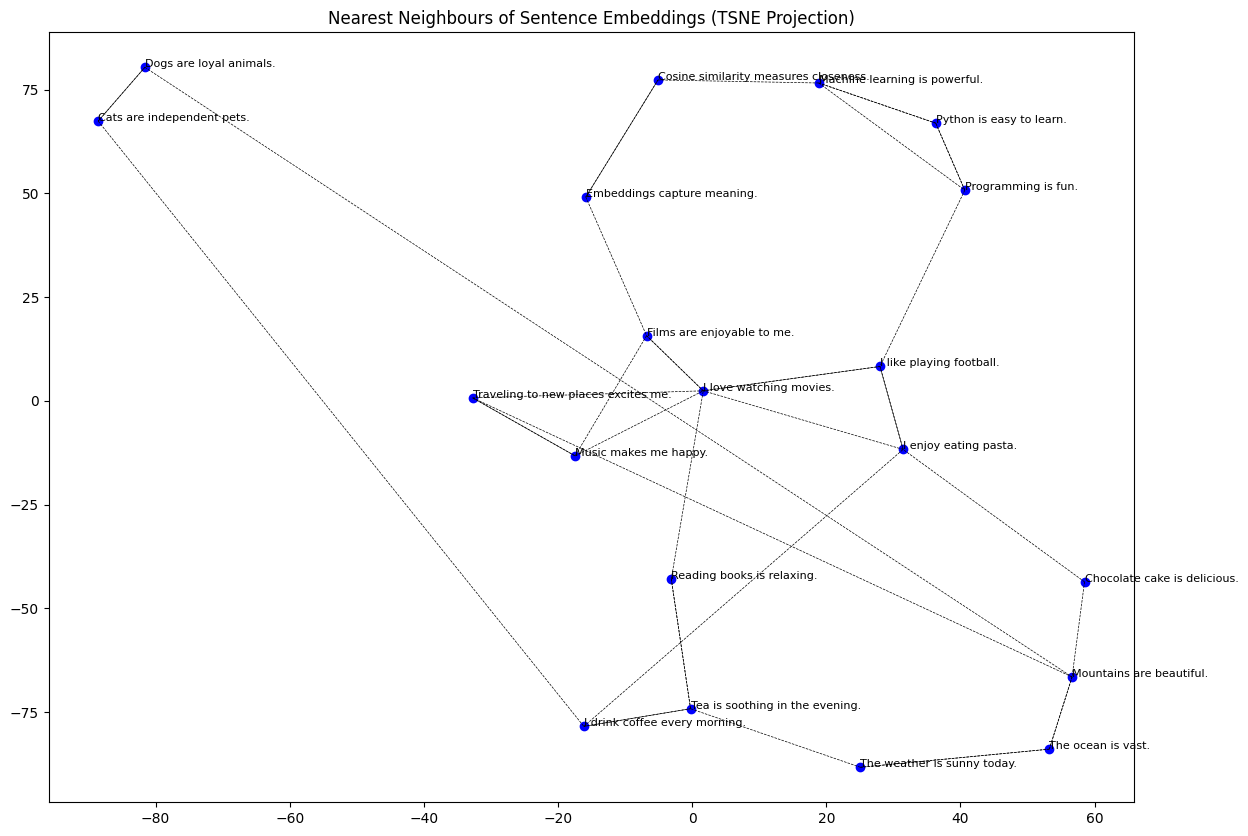

In [12]:
# Step 6: Plot with sentences as labels
plt.figure(figsize=(14, 10))
for i, (x, y) in enumerate(embeddings_2d):
    plt.scatter(x, y, color="blue")
    plt.text(x+0.01, y+0.01, sentences[i], fontsize=8)  # show sentence text
    
    # Draw lines to nearest neighbours
    for j in indices[i][1:]:  # skip self
        x2, y2 = embeddings_2d[j]
        plt.plot([x, x2], [y, y2], "k--", linewidth=0.5)

plt.title("Nearest Neighbours of Sentence Embeddings (TSNE Projection)")
plt.show()